In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

df = yf.download("AMZN", start="2012-01-01", end="2024-01-01")
close_prices = df[["Close"]].values

scaler = MinMaxScaler(feature_range=(-1, 1))
scaled_prices = scaler.fit_transform(close_prices)

def create_sequences(data, lookback=20):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

lookback = 20
X, y = create_sequences(scaled_prices, lookback)

split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

print(X_train_t.shape, y_train_t.shape)

[*********************100%***********************]  1 of 1 completed

torch.Size([2398, 20, 1]) torch.Size([2398, 1])


In [3]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # h0, c0: başlangıç gizli durumu ve hücre durumu, sıfırdan başlıyoruz
        h0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size)
        c0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size)

        out, _ = self.lstm(x, (h0, c0))   # out: (batch, seq_len, hidden_size)
        out = out[:, -1, :]               # sadece son zaman adımının çıktısını al
        out = self.fc(out)                # 1 sayıya (fiyat tahminine) indir
        return out

lstm_model = LSTMModel()
print(lstm_model)

LSTMModel(
  (lstm): LSTM(1, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [4]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(self.gru.num_layers, x.size(0), self.gru.hidden_size)
        out, _ = self.gru(x, h0)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

gru_model = GRUModel()
print(gru_model)

GRUModel(
  (gru): GRU(1, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [5]:
def train_model(model, X_train, y_train, epochs=100, lr=0.01):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")

    return losses

In [6]:
import time

start = time.time()
lstm_losses = train_model(lstm_model, X_train_t, y_train_t, epochs=100, lr=0.01)
lstm_time = time.time() - start
print(f"LSTM eğitim süresi: {lstm_time:.2f} saniye")

Epoch 10/100, Loss: 0.131386
Epoch 20/100, Loss: 0.019705
Epoch 30/100, Loss: 0.008265
Epoch 40/100, Loss: 0.004238
Epoch 50/100, Loss: 0.001601
Epoch 60/100, Loss: 0.001299
Epoch 70/100, Loss: 0.000807
Epoch 80/100, Loss: 0.000738
Epoch 90/100, Loss: 0.000683
Epoch 100/100, Loss: 0.000652
LSTM eğitim süresi: 8.91 saniye


In [7]:
start = time.time()
gru_losses = train_model(gru_model, X_train_t, y_train_t, epochs=100, lr=0.01)
gru_time = time.time() - start
print(f"GRU eğitim süresi: {gru_time:.2f} saniye")

Epoch 10/100, Loss: 0.003840
Epoch 20/100, Loss: 0.016204
Epoch 30/100, Loss: 0.006092
Epoch 40/100, Loss: 0.002654
Epoch 50/100, Loss: 0.001382
Epoch 60/100, Loss: 0.000872
Epoch 70/100, Loss: 0.000634
Epoch 80/100, Loss: 0.000542
Epoch 90/100, Loss: 0.000501
Epoch 100/100, Loss: 0.000466
GRU eğitim süresi: 12.82 saniye


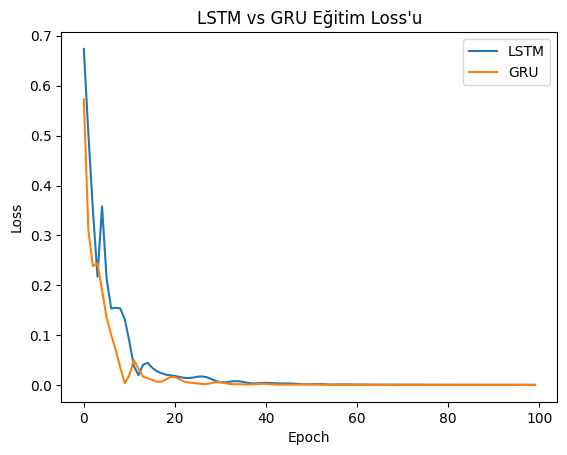

In [8]:
plt.plot(lstm_losses, label="LSTM")
plt.plot(gru_losses, label="GRU")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("LSTM vs GRU Eğitim Loss'u")
plt.show()

In [9]:
lstm_model.eval()
gru_model.eval()

with torch.no_grad():
    lstm_pred_scaled = lstm_model(X_test_t)
    gru_pred_scaled = gru_model(X_test_t)

print(lstm_pred_scaled.shape, gru_pred_scaled.shape)

torch.Size([600, 1]) torch.Size([600, 1])


In [10]:
lstm_pred = scaler.inverse_transform(lstm_pred_scaled.numpy())
gru_pred = scaler.inverse_transform(gru_pred_scaled.numpy())
y_test_real = scaler.inverse_transform(y_test_t.numpy())

print(lstm_pred[:5].flatten())
print(gru_pred[:5].flatten())
print(y_test_real[:5].flatten())

[168.71074 167.96875 167.32994 166.8331  166.1662 ]
[164.81981 164.70184 164.52776 164.5832  163.14467]
[165.175  164.6985 164.9495 162.098  160.061 ]


In [11]:
def evaluate(y_true, y_pred, name):
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    print(f"{name} -> MSE: {mse:,.4f} | RMSE: {rmse:,.4f}")
    return mse, rmse

lstm_mse, lstm_rmse = evaluate(y_test_real, lstm_pred, "LSTM")
gru_mse, gru_rmse = evaluate(y_test_real, gru_pred, "GRU")

LSTM -> MSE: 25.0663 | RMSE: 5.0066
GRU -> MSE: 16.2966 | RMSE: 4.0369


In [12]:
results_df = pd.DataFrame({
    "Model": ["LSTM", "GRU"],
    "MSE": [lstm_mse, gru_mse],
    "RMSE": [lstm_rmse, gru_rmse],
    "Egitim Suresi (s)": [lstm_time, gru_time]
})
results_df

,Model,MSE,RMSE,Egitim Suresi (s)
0,LSTM,25.066334,5.006629,8.914487
1,GRU,16.296602,4.036905,12.823348


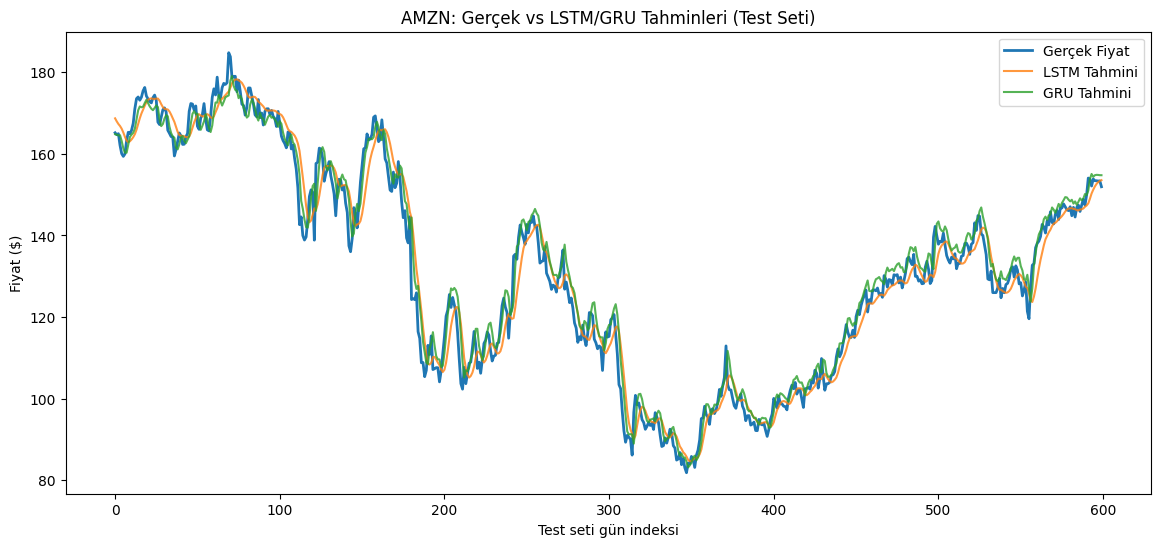

<Figure size 640x480 with 0 Axes>

In [16]:
plt.figure(figsize=(14, 6))
plt.plot(y_test_real, label="Gerçek Fiyat", linewidth=2)
plt.plot(lstm_pred, label="LSTM Tahmini", alpha=0.8)
plt.plot(gru_pred, label="GRU Tahmini", alpha=0.8)
plt.xlabel("Test seti gün indeksi")
plt.ylabel("Fiyat ($)")
plt.title("AMZN: Gerçek vs LSTM/GRU Tahminleri (Test Seti)")
plt.legend()
plt.show()
plt.savefig("../results/lstm_vs_gru_predictions.png", dpi=150, bbox_inches="tight")

In [14]:
# Naive baseline: bir önceki günün gerçek fiyatını, bugünün tahmini olarak kullan
naive_pred = y_test_real[:-1]   # dünün gerçek değerleri
naive_true = y_test_real[1:]    # bugünün gerçek değerleri

naive_mse, naive_rmse = evaluate(naive_true, naive_pred, "Naive Baseline")

Naive Baseline -> MSE: 10.1467 | RMSE: 3.1854


In [15]:
comparison_df = pd.DataFrame({
    "Model": ["LSTM", "GRU", "Naive Baseline"],
    "RMSE": [lstm_rmse, gru_rmse, naive_rmse]
})
comparison_df

,Model,RMSE
0,LSTM,5.006629
1,GRU,4.036905
2,Naive Baseline,3.185392


## Sonuç ve Değerlendirme

| Model | RMSE ($) |
|---|---|
| LSTM | 5.01 |
| GRU | 4.04 |
| Naive Baseline | 3.19 |

GRU, LSTM'e göre daha düşük hata verdi (RMSE açısından daha başarılı), ancak eğitim süresi
daha uzundu (12.82s vs 8.91s) — bu, planın referans aldığı kaynaktaki "GRU daha hızlı"
beklentisinin tersi bir sonuç, muhtemelen bu deneydeki küçük veri/model boyutu ve donanım
farklarından kaynaklanıyor.

Daha önemlisi: basit bir "naive baseline" (yarının fiyatı bugünküyle aynıdır varsayımı),
hem LSTM'den hem GRU'dan daha düşük RMSE verdi. Bu, hisse fiyatlarının kısa vadede
büyük ölçüde öngörülemez (random walk'a yakın) davrandığını ve karmaşık modellerin bu
tür verilerde otomatik olarak avantaj sağlamadığını gösteriyor. Bu proje, bir modelin
"düşük hata" vermesinin tek başına "gerçekten öngörücü" olduğu anlamına gelmediğini
göstermesi açısından öğretici oldu.